# Performance Optimization and Fairness Evaluation in Census Income Prediction

## 1. Project Overview
This project compares multiple classification algorithms, applies hyperparameter optimization, evaluates models using multiple performance metrics, analyzes fairness across demographic groups, and examines feature importance.

### Key Components
- Exploratory Data Analysis (EDA)
- Data preprocessing using Scikit-learn Pipelines
- Logistic Regression, Random Forest, SVM, Gradient Boosting, and XGBoost
- Hyperparameter tuning using GridSearchCV
- Multi-metric model evaluation
- Fairness analysis
- Feature importance analysis

## Table of Contents

1. Project Overview
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Exploratory Data Analysis
6. Target Encoding and Feature Separation
7. Preprocessing Pipeline
8. Train-Test Split
9. Baseline Model Training and Comparison
10. Random Forest Hyperparameter Tuning
11. Tuned Model Evaluation
12. Fairness Analysis
13. Feature Importance
14. Key Findings
15. Limitations and Future Work
16. Conclusion

## 2. Import libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('images', exist_ok=True)
print("Directory 'images/' ensured to exist.")

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Optional advanced model
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Directory 'images/' ensured to exist.


## 3. Load Dataset

In [ ]:
columns = [
    'age','workclass','fnlwgt','education','education-num','marital-status',
    'occupation','relationship','race','sex','capital-gain','capital-loss',
    'hours-per-week','native-country','income'
]

df = pd.read_csv("adult.csv", names=columns, skipinitialspace=True)

# View data
print(df.head())
print(df.columns)

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

### 3.1 Initial Dataset Inspection

Before preprocessing, the dataset is inspected to understand its dimensions, feature data types, missing values, and target class distribution.

In [ ]:
print(f"Dataset shape: {df.shape}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['income'].value_counts())

Dataset shape: (32561, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Target distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


## 4. Data Cleaning

In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Strip whitespace from categorical values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Verify missing values
print("Missing values after cleaning: ")
print(df.isnull().sum())

Missing values after cleaning: 
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Age Distribution

The age distribution helps identify the demographic composition of the dataset and potential skewness in the age feature.

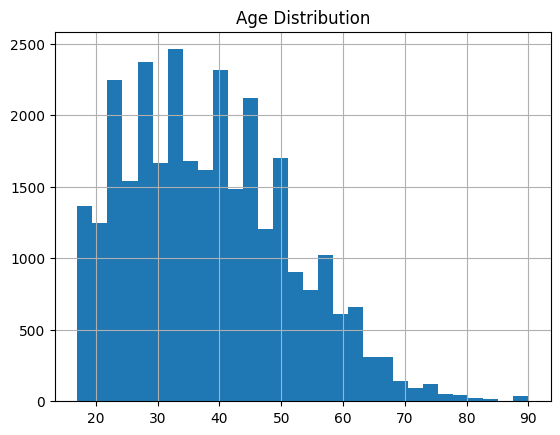

<Figure size 640x480 with 0 Axes>

In [ ]:
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()
plt.savefig(
    "images/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

### 5.2 Income Class Distribution
The distribution of the target variable is examined to identify potential class imbalance between individuals earning `<=50K` and those earning `>50K`. Understanding this imbalance is important because it can affect model training and evaluation, particularly metrics such as precision, recall, and F1-score.

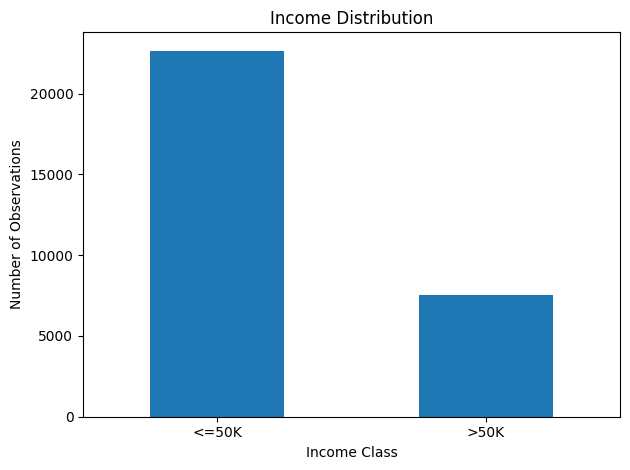

<Figure size 640x480 with 0 Axes>

In [ ]:
df['income'].value_counts().plot(kind='bar')

plt.title("Income Distribution")
plt.xlabel("Income Class")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig(
    "images/income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

### 5.3 Correlation Analysis
A correlation heatmap is used to examine linear relationships among the numerical features in the dataset. This analysis helps identify potentially related variables and provides insight into the structure of the numerical feature space. However, correlation captures only linear relationships and does not fully represent associations involving categorical variables or non-linear patterns.

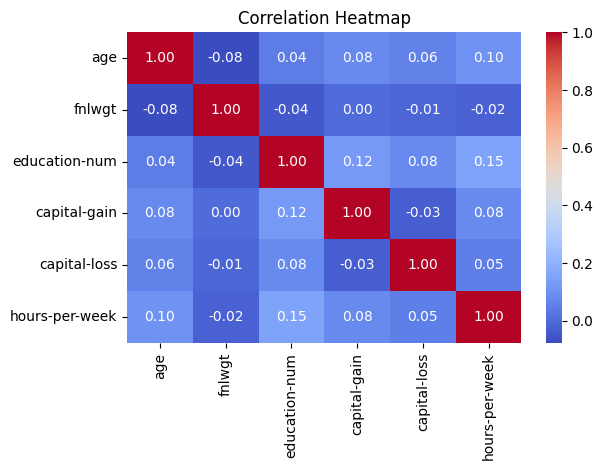

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.savefig(
    "images/Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

### 5.4 Education Level vs. Income
The relationship between education level and income class is examined to understand how income outcomes vary across different educational categories. The visualization compares the frequency of `<=50K` and `>50K` income observations within each education group and highlights differences in income distribution across educational backgrounds.

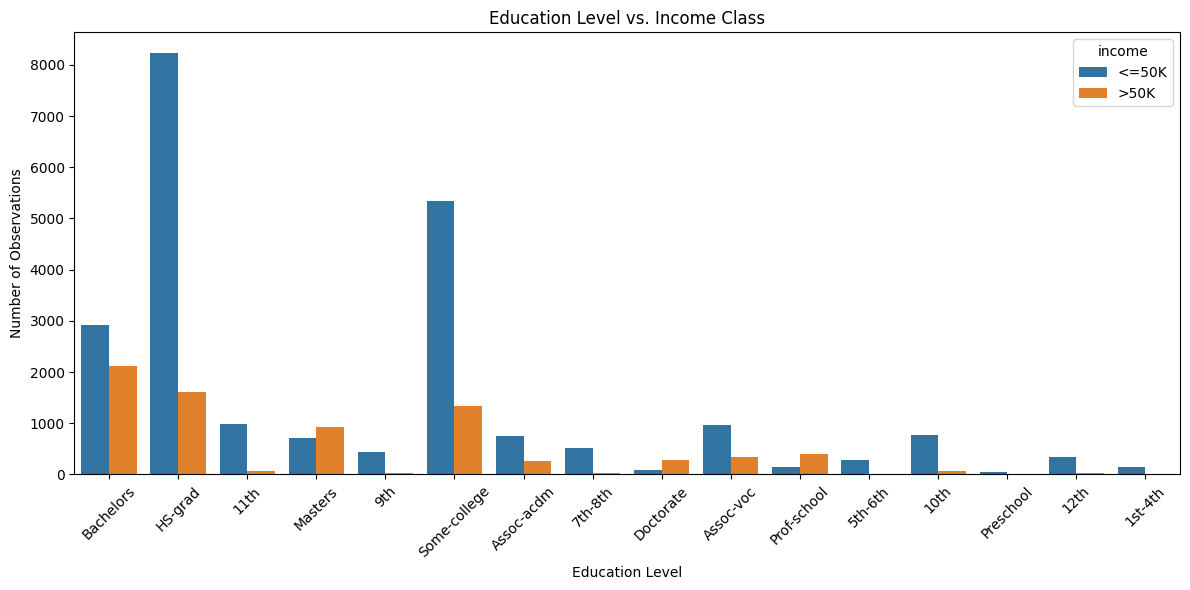

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(x='education', hue='income', data=df)

plt.title("Education Level vs. Income Class")
plt.xlabel("Education Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(
    "images/Education_Level_Vs_Income_Class",
    dpi=300,
    bbox_inches="tight"
)

### Key EDA Observations

- The target variable is imbalanced, with the `<=50K` class representing the majority of observations.
- Several numerical variables, particularly capital-related features, exhibit skewed distributions.
- Education and other socio-economic attributes show meaningful relationships with income.
- The relationships between features and income are not purely linear, motivating the use of ensemble and non-linear classification models.

## 6. Target Encoding and Feature Seperation

### Feature Engineering

The target variable is converted to a binary representation. The feature matrix and target vector are separated, followed by identification of numerical and categorical attributes for preprocessing.

In [ ]:
# Convert income to binary
df['income'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

X = df.drop('income', axis=1)
y = df['income']

categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

## 7. Preprocessing Pipeline

In [ ]:
# Numerical scaling
num_transformer = StandardScaler()

# Categorical encoding
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

## 8. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

## 9. Baseline Model Training and Comparison

In [ ]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Display results
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)

print(results_df.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost                0.8644     0.7689  0.6511  0.7051   0.9237
Gradient Boosting      0.8598     0.7837  0.6032  0.6817   0.9163
Logistic Regression    0.8475     0.7354  0.6052  0.6640   0.9022
Random Forest          0.8488     0.7287  0.6258  0.6734   0.9007
SVM                    0.8498     0.7500  0.5952  0.6637   0.8983


### 9.1 Baseline Model Performance Analysis

The baseline comparison evaluates all five classification models using Accuracy, Precision, Recall, F1-score, and ROC-AUC, providing a broader assessment than relying on accuracy alone.

The results indicate that ensemble and boosting-based methods generally provide stronger predictive performance than the linear baseline. XGBoost achieves the strongest overall performance across the evaluated metrics, while Gradient Boosting also performs competitively.

The differences between precision and recall highlight the effect of class imbalance in the dataset. In particular, predicting the minority `>50K` class remains more challenging than predicting the majority `<=50K` class.

Based on the overall comparison, XGBoost emerges as the strongest baseline model, demonstrating that boosting-based methods are well suited to capturing the complex and potentially non-linear relationships present in the Adult dataset.

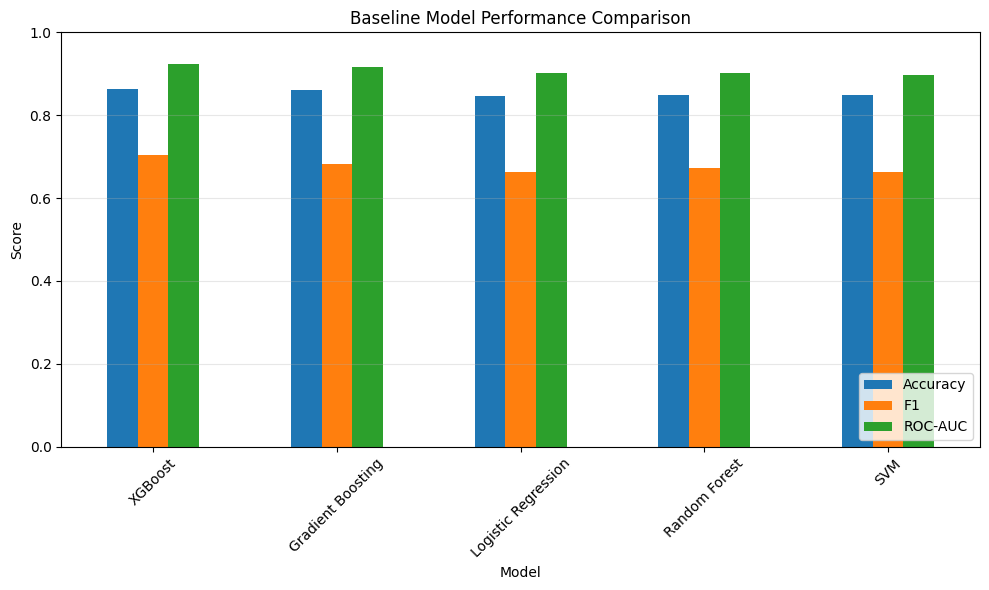

<Figure size 640x480 with 0 Axes>

In [ ]:
results_df[['Accuracy', 'F1', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)
plt.grid(axis='y', alpha=0.3)
plt.title('Baseline Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.savefig(
    "images/baseline_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

The visualization reinforces the numerical comparison by highlighting differences in Accuracy, F1-score, and ROC-AUC across the five baseline models. ROC-AUC is particularly useful in this context because it evaluates the model's ability to distinguish between income classes across different classification thresholds.

## 10. Random Forest Hyperparameter Tuning
Random Forest was selected as a representative ensemble model for demonstrating systematic hyperparameter optimization. GridSearchCV with stratified 5-fold cross-validation is used to optimize the model based on F1-score.

The objective of this stage is to evaluate the effect of hyperparameter tuning on a baseline model rather than to exhaustively optimize every classifier.

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}


## 11. Tuned Model Evaluation

### 11.1 Classification Report

In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8552958727001492
F1 Score: 0.686084142394822
ROC-AUC: 0.9087583802777786

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91      4531
           1       0.75      0.64      0.69      1502

    accuracy                           0.86      6033
   macro avg       0.82      0.78      0.80      6033
weighted avg       0.85      0.86      0.85      6033



### 11.2 Confusion Matrix

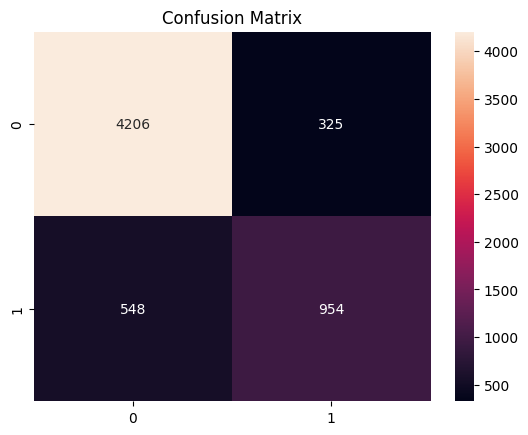

<Figure size 640x480 with 0 Axes>

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
plt.savefig(
    "images/Confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

### 11.3 ROC Curve

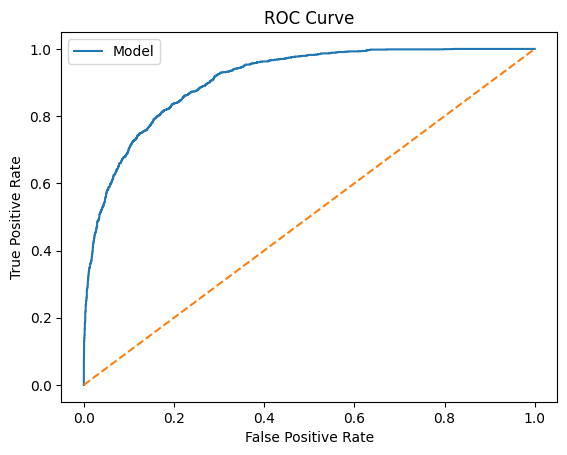

<Figure size 640x480 with 0 Axes>

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
plt.savefig(
    "images/ROC_curve.png",
    dpi=300,
    bbox_inches="tight"
)

## 12. Fairness Analysis

Select Sensitive Attribute

In [ ]:
sensitive_attr = 'sex'

df_test = X_test.copy()
df_test['actual'] = y_test.values
df_test['predicted'] = y_pred
df_test[sensitive_attr] = X_test[sensitive_attr]

### 12.1 Demographic Parity

In [ ]:
grouped = df_test.groupby(sensitive_attr)['predicted'].mean()
print("Demographic Parity:\n", grouped)

Demographic Parity:
 sex
Female    0.094004
Male      0.269127
Name: predicted, dtype: float64


### 12.2 Equal Opportunity (TPR)

In [ ]:
def tpr(group):
    tp = ((group['actual']==1) & (group['predicted']==1)).sum()
    fn = ((group['actual']==1) & (group['predicted']==0)).sum()
    return tp / (tp + fn + 1e-6)

tpr_values = df_test.groupby(sensitive_attr).apply(tpr)
print("Equal Opportunity (TPR):\n", tpr_values)

Equal Opportunity (TPR):
 sex
Female    0.600000
Male      0.641673
dtype: float64


### 12.3 Disparate Impact

In [ ]:
female_positive_rate = grouped.get('Female', np.nan)
male_positive_rate = grouped.get('Male', np.nan)

disparate_impact_ratio = female_positive_rate / male_positive_rate

print(
    "Disparate Impact Ratio (Female / Male):",
    disparate_impact_ratio
)

Disparate Impact Ratio (Female / Male): 0.3492929839033308


The disparate impact ratio compares the positive prediction rate for females with the positive prediction rate for males. A value substantially below 1 indicates that positive predictions occur at a lower rate for females in this model.

This metric should be interpreted as an indicator of outcome disparity rather than, by itself, definitive evidence of unlawful or causal discrimination. Differences in the underlying dataset, historical patterns, feature distributions, and model behavior may all contribute to the observed disparity.

## 13. Feature Importance

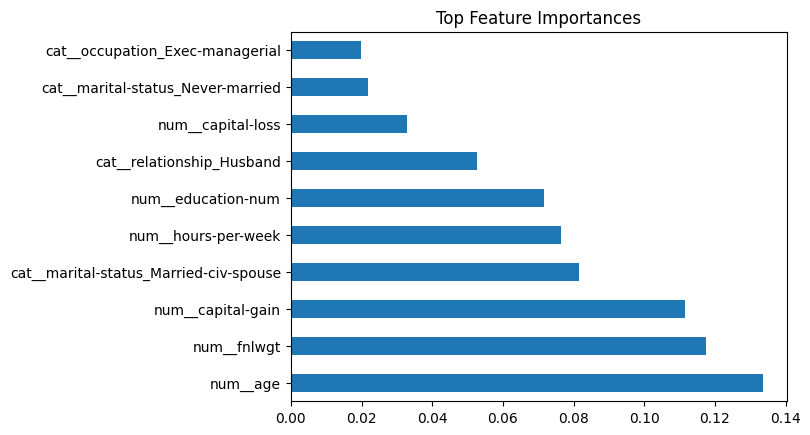

<Figure size 640x480 with 0 Axes>

In [ ]:
model = best_model.named_steps['model']

importances = model.feature_importances_

# Get feature names
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top Feature Importances")
plt.show()
plt.savefig(
    "images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

## 14. Key Findings

- Ensemble and boosting models generally outperformed linear models on the income classification task.
- XGBoost achieved the strongest overall baseline predictive performance in the model comparison.
- Hyperparameter optimization improved the Random Forest model relative to its baseline configuration, although model selection had a substantial impact on overall performance.
- Performance on the higher-income minority class remained weaker than on the majority class, particularly in terms of recall.
- Fairness evaluation revealed substantial differences in positive prediction rates across sex groups.
- Feature importance analysis identified several socio-economic and demographic variables as influential predictors.

Overall, the results demonstrate that evaluating machine learning systems solely on aggregate predictive performance can overlook important differences in model behavior across demographic groups.

## 15. Limitations and Future Work

### Limitations

- Hyperparameter optimization was performed only for Random Forest.
- The dataset represents historical census data and may contain historical societal biases.
- Fairness evaluation was primarily conducted with respect to sex.
- The analysis identifies statistical disparities but does not establish causal discrimination.
- No fairness mitigation techniques were implemented.
- The project focuses on offline model evaluation and does not include deployment.

### Future Work

- Extend hyperparameter optimization to additional models, particularly XGBoost.
- Evaluate fairness across additional sensitive attributes and intersectional groups.
- Apply and compare bias mitigation techniques.
- Investigate threshold optimization and performance-fairness trade-offs.
- Incorporate model explainability techniques such as SHAP.
- Develop a lightweight deployment interface for model demonstration.

## 16. Conclusion

This project demonstrates a complete machine learning workflow for income classification using the UCI Adult dataset. Multiple supervised learning algorithms were evaluated using comprehensive performance metrics, with XGBoost providing the strongest baseline performance. Hyperparameter optimization improved the Random Forest model, while fairness evaluation revealed meaningful demographic disparities that highlight the importance of evaluating machine learning systems beyond predictive accuracy alone.

Overall, the project illustrates the integration of data preprocessing, model development, evaluation, optimization, and responsible AI considerations into a single reproducible pipeline.